In [12]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from typing import TypedDict
from dotenv import load_dotenv
import os

In [13]:
load_dotenv()  # Load environment variables from .env file

True

In [14]:
model = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

In [15]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [16]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title
    title = state.get("title", "")

    # call llm gen outline
    prompt = f"Generate an outline for a blog on the topic of '{title}'"
    outline=model.invoke(prompt).content

    # update state
    state['outline']=outline
    return state
   

In [17]:
def create_blog(state: BlogState) -> BlogState:
    # fetch outline
    title = state.get("title", "")
    outline = state.get("outline", "")

    # call llm gen blog content
    prompt = f"Write a blog on the title: '{title}' using the following outline:\n{outline}"
    content=model.invoke(prompt).content

    # update state
    state['content']=content
    return state

In [18]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# complite graph
workflow = graph.compile()




In [30]:
initial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)
print("Final State:", final_state)
print("title:", final_state['title'])
print(final_state['outline'])
print(final_state['content'])

Final State: {'title': 'Rise of AI in India', 'outline': 'Certainly! Here’s an outline for a blog on the topic of "The Rise of AI in India":\n\n### Title: The Rise of AI in India: Shaping the Future of Technology and Society\n\n### Introduction\n- Brief introduction to the global AI landscape\n- Highlight the importance of AI in today\'s world\n- Introduce the focus on India and its growing prominence in the AI domain\n\n### Section 1: Background and Overview of AI in India\n- Historical context of the Indian IT industry\n- Government initiatives and policies promoting AI (e.g., National Strategy for Artificial Intelligence)\n- Overview of the current AI ecosystem in India\n\n### Section 2: Key Players and Innovations\n- Major Indian AI companies and startups (e.g., Swastica, Ramco Systems, HaptiMD)\n- University and academic research centers (e.g., IITs, IISc, BITS Pilani)\n- Collaboration between public and private sectors (e.g., NITI Aayog’s AI startups initiative)\n\n### Section 3:

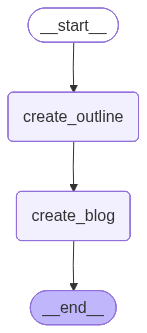

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())